# Libraries

In [1]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider

# Select the patient and the acquisition parameters

In [2]:
dir="./Patient_1"
data = loadmat(f"{dir}/diffavg_qb32_D19.mat")

# Investigate the file

In [3]:
print(data.keys())
print(data["__header__"])
print(data["__version__"])
print(data["__globals__"])
#print(data["b0all"])

dict_keys(['__header__', '__version__', '__globals__', 'diff_avg'])
b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Thu Oct  9 15:24:09 2025'
1.0
[]


In [4]:
name=list(data)[-1]
signal=data[name] #sagitarial plan
signal_t=np.transpose(signal, (0,2,1,3)) #transverse plan

In [5]:
print(f"Array shape is {signal.shape}")
print(f"The max of signal values is {np.max(signal)} at voxel {np.where(signal==np.max(signal))}")
print(f"Number of non-zero values is : {np.count_nonzero(signal)}")

Array shape is (108, 108, 66, 3)
The max of signal values is 1283.90625 at voxel (array([61]), array([14]), array([30]), array([0]))
Number of non-zero values is : 1983675


# Plot a slice

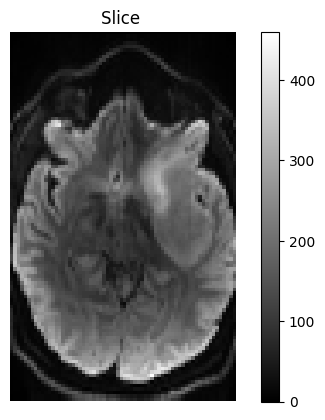

In [6]:
slice=signal_t[:,:,50,1]
plt.imshow(slice,cmap="gray")
plt.colorbar()
plt.title("Slice ")
plt.axis('off')
plt.show()

# Plot the volume 

In [7]:
volume=signal_t[:,:,:,4]

def plot_slice(z):
    plt.figure(figsize=(6, 6))
    plt.imshow(volume[:, :, z], cmap='gray')
    plt.title(f"Slice {z}")
    plt.axis('off')
    plt.show()

interact(
    plot_slice,
    z=IntSlider(min=0, max=signal_t.shape[2] - 1, step=1, value=0)
)

IndexError: index 4 is out of bounds for axis 3 with size 3